# PCA Factor Structure Analysis across Three Time Blocks

**Purpose:** This notebook investigates whether the underlying factor structure of the seven
price series is stable across time, using PCA applied separately to three equal chronological
blocks of the known historical data.

**This is a diagnostic / decision-support notebook.** It does *not* produce a price forecast.
Its outputs inform the choice of extrapolation method and time block in a separate notebook.

## Questions addressed

| # | Question |
|---|----------|
| 1 | How many common factors are needed to explain ≥ 90 % of co-movement? Does this change between blocks? |
| 2 | Do the same assets drive the same principal components in all three blocks (stable loadings)? |
| 3 | Does the pairwise correlation structure between assets shift over time? |
| 4 | How do factor scores evolve within each block — stable dynamics or changing volatility? |
| 5 | Which assets are well-represented by PCA and which are not, and does this vary by block? |
| 6 | What do all of the above imply for the extrapolation approach? |

## Data
- Source: `spiff_data-2_filled.csv` — 5 256 observations per series, internal gaps already
  interpolated.
- The known history is split into **three equal chronological blocks** (~1 752 observations each).
- PCA is fitted *separately* on each block. No data crosses block boundaries.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import acf

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 9,
})
CMAP_DIV = 'RdBu_r'   # diverging colormap centred at 0

print('Imports OK')

Imports OK


## 1. Load data

In [16]:
DATA_PATH = '../data/spiff_data-2_filled.csv'
df = pd.read_csv(DATA_PATH)

SERIES = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

prices_known = df[SERIES].values        # (5256, 7)  – all known history
days_known   = df['day'].values         # day 1 … 5256

N_KNOWN = len(prices_known)
assert df[SERIES].isna().sum().sum() == 0, 'Unexpected NaNs in filled data'

print(f'Known observations: {N_KNOWN}')
print(f'Series: {SERIES}')
df[SERIES].describe().round(3)

Known observations: 5256
Series: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
count,5256.000,5256.000,5256.000,5256.000,5256.000,5256.000,5256.000
mean,8.912,5.735,3.552,6.413,2.672,5.784,11.525
std,2.268,1.764,0.975,2.210,0.729,1.273,3.067
min,5.943,2.629,2.001,4.012,1.370,3.739,6.615
25%,6.931,4.193,2.785,4.922,2.004,4.976,9.131
50%,8.873,5.878,3.366,5.537,2.619,5.761,10.547
75%,10.168,7.038,4.283,7.100,3.293,6.480,13.342
max,14.132,10.719,6.469,13.613,4.125,8.949,21.138


## 2. Split into 3 chronological blocks

In [17]:
block_size = N_KNOWN // 3      # 1752

BLOCKS = {
    'block_1': (0,              block_size),
    'block_2': (block_size,     2 * block_size),
    'block_3': (2 * block_size, N_KNOWN),
}

block_1_prices = prices_known[BLOCKS['block_1'][0]:BLOCKS['block_1'][1]]
block_2_prices = prices_known[BLOCKS['block_2'][0]:BLOCKS['block_2'][1]]
block_3_prices = prices_known[BLOCKS['block_3'][0]:BLOCKS['block_3'][1]]

BLOCK_DATA   = {'block_1': block_1_prices,
                'block_2': block_2_prices,
                'block_3': block_3_prices}
BLOCK_LABELS = {'block_1': 'Block 1', 'block_2': 'Block 2', 'block_3': 'Block 3'}
BLOCK_DAYS   = {name: days_known[s:e]
                for name, (s, e) in BLOCKS.items()}

# No overlaps, no cross-block data
assert BLOCKS['block_1'][1] == BLOCKS['block_2'][0]
assert BLOCKS['block_2'][1] == BLOCKS['block_3'][0]

for name, (s, e) in BLOCKS.items():
    print(f'{name}: rows {s}–{e-1}  |  days {int(days_known[s])}–{int(days_known[e-1])}  |  n={e-s}')

block_1: rows 0–1751  |  days 1–1752  |  n=1752
block_2: rows 1752–3503  |  days 1753–3504  |  n=1752
block_3: rows 3504–5255  |  days 3505–5256  |  n=1752


## 3. Helper functions

In [18]:
# ── Data preparation ─────────────────────────────────────────────────────────

def compute_log_returns(price_block: np.ndarray) -> np.ndarray:
    """Log-returns within one block. Shape: (n-1, 7)."""
    return np.diff(np.log(price_block), axis=0)


def standardize_returns(returns: np.ndarray):
    """Fit StandardScaler on returns, return (scaler, scaled_returns)."""
    scaler = StandardScaler()
    return scaler, scaler.fit_transform(returns)


# ── PCA ───────────────────────────────────────────────────────────────────────

def run_pca_for_block(price_block: np.ndarray, var_threshold: float = 0.90) -> dict:
    """
    Full PCA pipeline for one block.
    Returns dict with all PCA objects and derived quantities.
    """
    returns           = compute_log_returns(price_block)
    scaler, scaled    = standardize_returns(returns)

    # Full PCA to get all eigenvalues
    pca_full = PCA(n_components=scaled.shape[1])
    pca_full.fit(scaled)
    ev  = pca_full.explained_variance_ratio_
    cum = np.cumsum(ev)
    n_comp = int(np.searchsorted(cum, var_threshold) + 1)

    # Reduced PCA
    pca    = PCA(n_components=n_comp)
    scores = pca.fit_transform(scaled)   # (n-1, n_comp)

    # Loadings: (n_series, n_comp)  — components_ has shape (n_comp, n_features)
    loadings = pca.components_.T        # (n_features, n_comp)

    return dict(
        returns=returns, scaler=scaler, scaled=scaled,
        pca_full=pca_full, pca=pca,
        ev=ev, cum=cum, n_comp=n_comp,
        loadings=loadings,              # (7, n_comp)
        scores=scores,                  # (n-1, n_comp)
    )


# ── Visualisation helpers ─────────────────────────────────────────────────────

def plot_explained_variance(ax_bar, ax_cum, ev, cum, n_comp, title):
    x      = np.arange(1, len(ev) + 1)
    colors = ['steelblue' if i < n_comp else 'lightgrey' for i in range(len(ev))]
    ax_bar.bar(x, ev, color=colors, edgecolor='k', linewidth=0.4)
    ax_bar.set_title(title, fontsize=9)
    ax_bar.set_xlabel('PC'); ax_bar.set_ylabel('Indiv. var.')

    ax_cum.plot(x, cum, 'r-o', ms=4)
    ax_cum.axhline(0.90, color='red', ls='--', lw=0.9, label='90 %')
    ax_cum.set_ylim(0, 1.05)
    ax_cum.set_title(title + ' – cumulative', fontsize=9)
    ax_cum.set_xlabel('PC'); ax_cum.set_ylabel('Cum. var.')
    ax_cum.legend(fontsize=7, loc='lower right')


def plot_loadings_heatmap(ax, loadings, series, n_comp, title):
    """Heatmap of PCA loadings (series × components)."""
    data = loadings[:, :n_comp]
    vmax = np.abs(data).max()
    sns.heatmap(
        pd.DataFrame(data, index=series,
                     columns=[f'PC{i+1}' for i in range(n_comp)]),
        ax=ax, cmap=CMAP_DIV, center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        linewidths=0.3, cbar_kws={'shrink': 0.7},
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=8)


def summarize_component_loadings(loadings, series, n_comp, block_name):
    """Print top-3 positive and negative loadings per component."""
    print(f'\n{block_name} — top loadings per component')
    for k in range(n_comp):
        col = loadings[:, k]
        pos = sorted(zip(col, series), reverse=True)[:3]
        neg = sorted(zip(col, series))[:3]
        pos_str = ', '.join(f'{s}({v:+.2f})' for v, s in pos)
        neg_str = ', '.join(f'{s}({v:+.2f})' for v, s in neg)
        print(f'  PC{k+1}  +: {pos_str}   –: {neg_str}')


def plot_correlation_heatmap(ax, corr, title):
    sns.heatmap(
        pd.DataFrame(corr, index=SERIES, columns=SERIES),
        ax=ax, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 6.5},
        linewidths=0.3, cbar_kws={'shrink': 0.7},
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)


def compare_loading_similarity(L1, L2) -> np.ndarray:
    """
    Absolute cosine similarity matrix between loading columns of two blocks.
    L1, L2 : (n_series, n_comp_i), (n_series, n_comp_j)
    Returns (n_comp_i, n_comp_j) absolute cosine similarity.
    """
    L1n = L1 / (np.linalg.norm(L1, axis=0, keepdims=True) + 1e-12)
    L2n = L2 / (np.linalg.norm(L2, axis=0, keepdims=True) + 1e-12)
    return np.abs(L1n.T @ L2n)      # (n_comp_i, n_comp_j)


def compute_reconstruction_error(scaled, pca) -> np.ndarray:
    """RMSE per series between original and PCA reconstruction (standardised space)."""
    reconstructed = pca.inverse_transform(pca.transform(scaled))
    return np.sqrt(np.mean((scaled - reconstructed) ** 2, axis=0))


print('Helper functions defined.')

Helper functions defined.


## 4. Fit PCA on each block

In [19]:
block_pca = {}

for name, bp in BLOCK_DATA.items():
    block_pca[name] = run_pca_for_block(bp)
    m   = block_pca[name]
    print(f'\n{BLOCK_LABELS[name]}: n_comp={m["n_comp"]}  '
          f'(cum var = {m["cum"][m["n_comp"]-1]:.4f})')


Block 1: n_comp=6  (cum var = 0.9365)

Block 2: n_comp=6  (cum var = 0.9505)

Block 3: n_comp=6  (cum var = 0.9582)


## 5. Explained variance per block

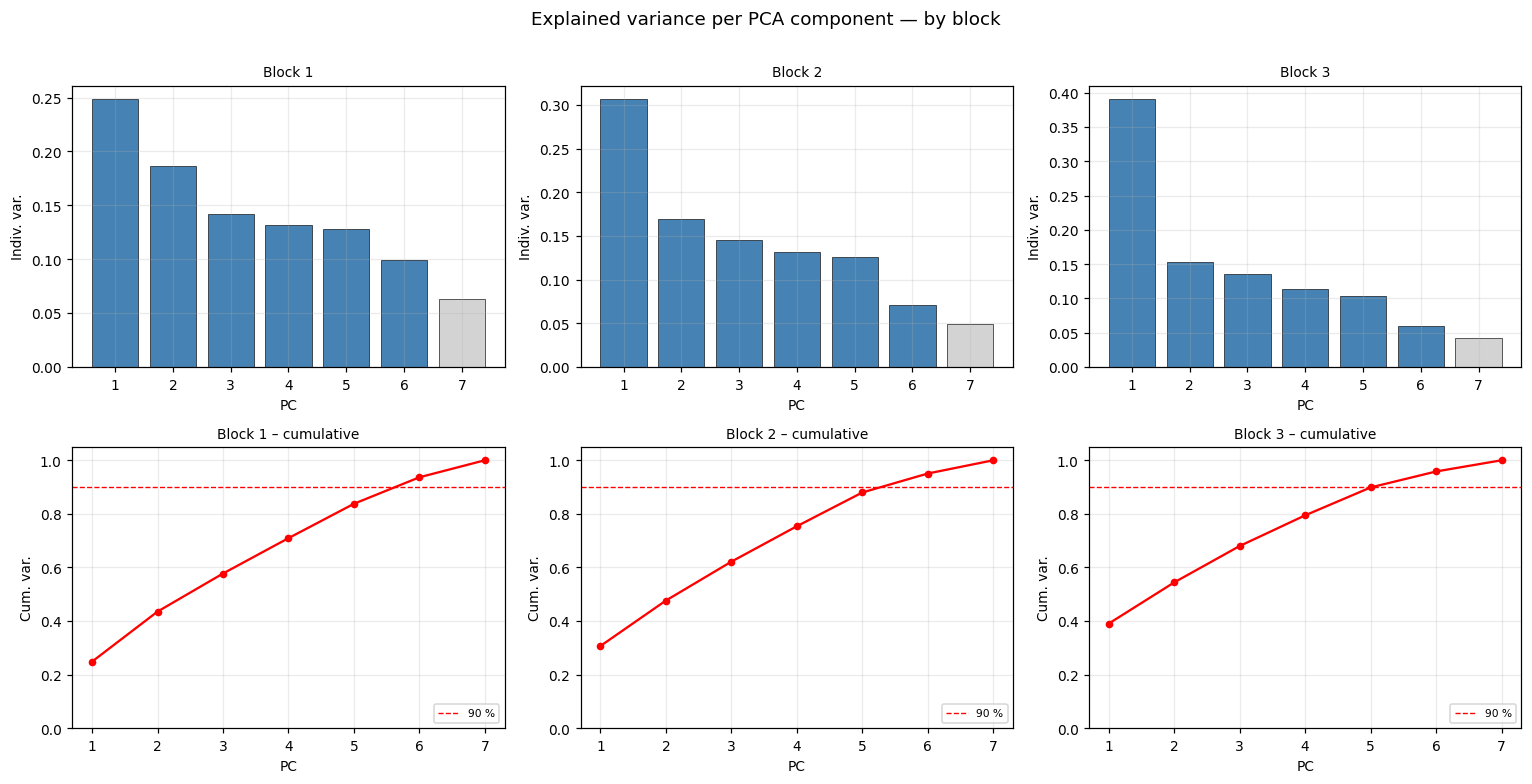

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col, name in enumerate(['block_1', 'block_2', 'block_3']):
    m = block_pca[name]
    plot_explained_variance(
        axes[0, col], axes[1, col],
        m['ev'], m['cum'], m['n_comp'],
        BLOCK_LABELS[name]
    )

fig.suptitle('Explained variance per PCA component — by block', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Summary table
rows = []
for name in ['block_1', 'block_2', 'block_3']:
    m = block_pca[name]
    ev = m['ev']
    rows.append({
        'Block': BLOCK_LABELS[name],
        'n_comp for 90%': m['n_comp'],
        'Cum var (n_comp)': f'{m["cum"][m["n_comp"]-1]:.3f}',
        'PC1 var': f'{ev[0]:.3f}',
        'PC2 var': f'{ev[1]:.3f}',
        'PC3 var': f'{ev[2]:.3f}',
    })
summary_ev = pd.DataFrame(rows).set_index('Block')
print('Explained variance summary:')
display(summary_ev)

Explained variance summary:


,n_comp for 90%,Cum var (n_comp),PC1 var,PC2 var,PC3 var
Block,,,,,
Block 1,6,0.937,0.249,0.187,0.142
Block 2,6,0.951,0.307,0.170,0.145
Block 3,6,0.958,0.391,0.154,0.136


## 6. PCA loadings heatmaps per block

Each cell shows how strongly each asset contributes to each principal component.
A loading near +1 or –1 means that asset is a primary driver of that factor;
near 0 means it contributes little.


Block 1 — top loadings per component
  PC1  +: water(+0.55), gurkor(+0.50), guitars(+0.49)   –: tranquillity(-0.10), stocks(-0.06), sugar(+0.16)
  PC2  +: sugar(+0.50), tranquillity(+0.43), guitars(+0.38)   –: gurkor(-0.39), water(-0.33), stocks(+0.13)
  PC3  +: stocks(+0.97), water(+0.15), gurkor(+0.14)   –: slingshots(-0.09), guitars(-0.07), sugar(-0.03)

Block 2 — top loadings per component
  PC1  +: gurkor(+0.50), water(+0.49), stocks(-0.04)   –: guitars(-0.50), slingshots(-0.42), sugar(-0.21)
  PC2  +: water(+0.47), gurkor(+0.45), tranquillity(+0.44)   –: stocks(-0.12), guitars(+0.27), sugar(+0.35)
  PC3  +: stocks(+0.90), slingshots(+0.14), guitars(+0.13)   –: sugar(-0.34), gurkor(+0.09), tranquillity(+0.09)

Block 3 — top loadings per component
  PC1  +: guitars(+0.51), slingshots(+0.44), tranquillity(+0.33)   –: water(-0.46), gurkor(-0.43), stocks(+0.03)
  PC2  +: stocks(+0.63), slingshots(-0.02), guitars(-0.12)   –: sugar(-0.58), gurkor(-0.30), tranquillity(-0.29)
  PC3  +: s

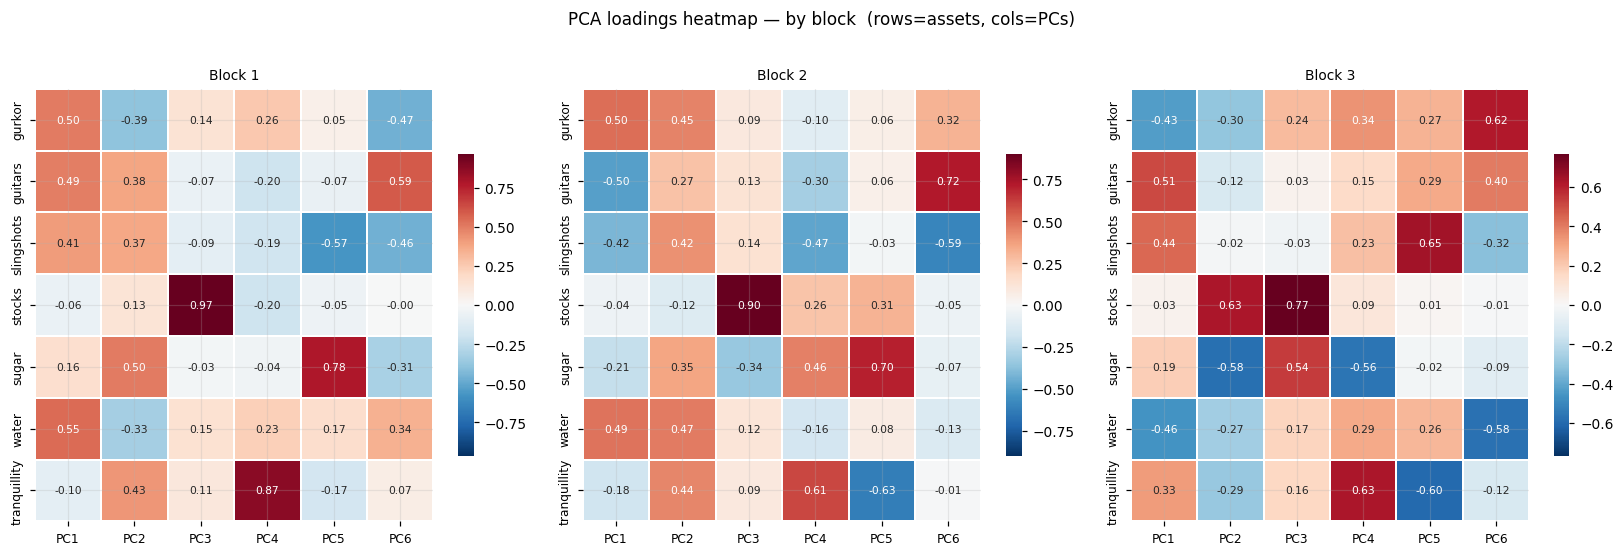

In [22]:
# Show PC1–PC6 (or all available) so blocks are visually comparable
MAX_PC = max(m['loadings'].shape[1] for m in block_pca.values())

fig, axes = plt.subplots(1, 3, figsize=(5 * 3, max(4, 0.7 * len(SERIES))))

for col, name in enumerate(['block_1', 'block_2', 'block_3']):
    m        = block_pca[name]
    n_show   = m['loadings'].shape[1]
    plot_loadings_heatmap(axes[col], m['loadings'], SERIES, n_show,
                          BLOCK_LABELS[name])
    summarize_component_loadings(m['loadings'], SERIES, min(3, n_show), BLOCK_LABELS[name])

fig.suptitle('PCA loadings heatmap — by block  (rows=assets, cols=PCs)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7. Cross-block loading comparison

Principal components can flip sign and reorder between separate PCA fits.
We use **absolute cosine similarity** between loading vectors to measure whether
the same underlying factor recurs across blocks, regardless of sign or ordering.

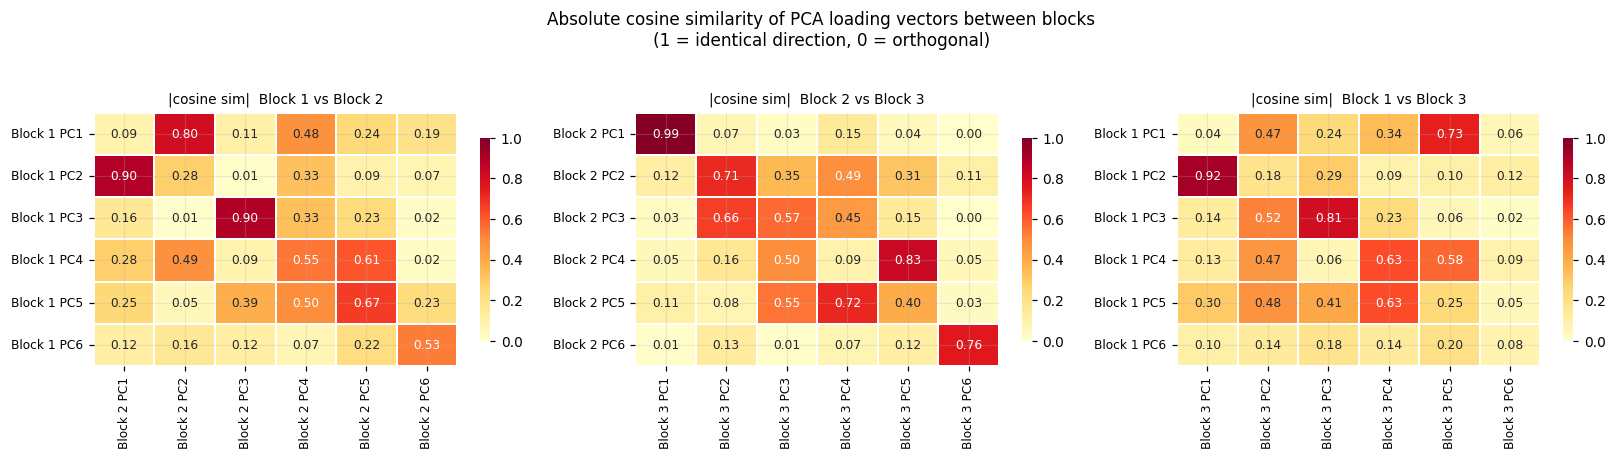

In [23]:
# ── Cosine similarity heatmaps ───────────────────────────────────────────────
pairs = [
    ('block_1', 'block_2', 'Block 1 vs Block 2'),
    ('block_2', 'block_3', 'Block 2 vs Block 3'),
    ('block_1', 'block_3', 'Block 1 vs Block 3'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sim_matrices = {}
for ax, (na, nb, title) in zip(axes, pairs):
    La = block_pca[na]['loadings']
    Lb = block_pca[nb]['loadings']
    sim = compare_loading_similarity(La, Lb)           # (n_comp_a, n_comp_b)
    sim_matrices[(na, nb)] = sim

    key = (na, nb)
    nr, nc = sim.shape
    df_sim = pd.DataFrame(
        sim,
        index  = [f'{BLOCK_LABELS[na][:7]} PC{i+1}' for i in range(nr)],
        columns= [f'{BLOCK_LABELS[nb][:7]} PC{j+1}' for j in range(nc)],
    )
    sns.heatmap(df_sim, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.3, cbar_kws={'shrink': 0.8})
    ax.set_title(f'|cosine sim|  {title}', fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle('Absolute cosine similarity of PCA loading vectors between blocks\n'
             '(1 = identical direction, 0 = orthogonal)', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

In [24]:
# ── Automatic interpretation ─────────────────────────────────────────────────
print('Cross-block loading similarity — interpretation\n' + '='*60)

for (na, nb, title), sim in zip(pairs, sim_matrices.values()):
    print(f'\n{title}')
    for i in range(sim.shape[0]):
        best_j   = np.argmax(sim[i])
        best_val = sim[i, best_j]
        stability = ('stable' if best_val >= 0.85
                     else 'moderate' if best_val >= 0.60
                     else 'unstable')
        print(f'  {BLOCK_LABELS[na]} PC{i+1} → {BLOCK_LABELS[nb]} PC{best_j+1}  '
              f'sim={best_val:.3f}  [{stability}]')

# Block 3 more similar to Block 2 or Block 1?
sim_12 = sim_matrices[('block_1', 'block_2')]
sim_13 = sim_matrices[('block_1', 'block_3')]
sim_23 = sim_matrices[('block_2', 'block_3')]

# Average max similarity per column (Block 3 PC compared to best match in B1 / B2)
avg_13 = np.mean(np.max(sim_13, axis=0))
avg_23 = np.mean(np.max(sim_23, axis=0))
closer = 'Block 1' if avg_13 > avg_23 else 'Block 2'
print(f'\nBlock 3 avg max-sim vs Block 1: {avg_13:.3f}')
print(f'Block 3 avg max-sim vs Block 2: {avg_23:.3f}')
print(f'=> Block 3 factor structure is most similar to: {closer}')

Cross-block loading similarity — interpretation

Block 1 vs Block 2
  Block 1 PC1 → Block 2 PC2  sim=0.805  [moderate]
  Block 1 PC2 → Block 2 PC1  sim=0.895  [stable]
  Block 1 PC3 → Block 2 PC3  sim=0.902  [stable]
  Block 1 PC4 → Block 2 PC5  sim=0.612  [moderate]
  Block 1 PC5 → Block 2 PC5  sim=0.670  [moderate]
  Block 1 PC6 → Block 2 PC6  sim=0.532  [unstable]

Block 2 vs Block 3
  Block 2 PC1 → Block 3 PC1  sim=0.985  [stable]
  Block 2 PC2 → Block 3 PC2  sim=0.713  [moderate]
  Block 2 PC3 → Block 3 PC2  sim=0.661  [moderate]
  Block 2 PC4 → Block 3 PC5  sim=0.834  [moderate]
  Block 2 PC5 → Block 3 PC4  sim=0.717  [moderate]
  Block 2 PC6 → Block 3 PC6  sim=0.759  [moderate]

Block 1 vs Block 3
  Block 1 PC1 → Block 3 PC5  sim=0.735  [moderate]
  Block 1 PC2 → Block 3 PC1  sim=0.921  [stable]
  Block 1 PC3 → Block 3 PC3  sim=0.806  [moderate]
  Block 1 PC4 → Block 3 PC4  sim=0.632  [moderate]
  Block 1 PC5 → Block 3 PC4  sim=0.630  [moderate]
  Block 1 PC6 → Block 3 PC5  sim=

## 8. Correlation structure comparison

How does the pairwise co-movement between assets change across blocks?
We compute correlation matrices of **standardised log-returns** for each block,
then plot the differences to highlight structural shifts.

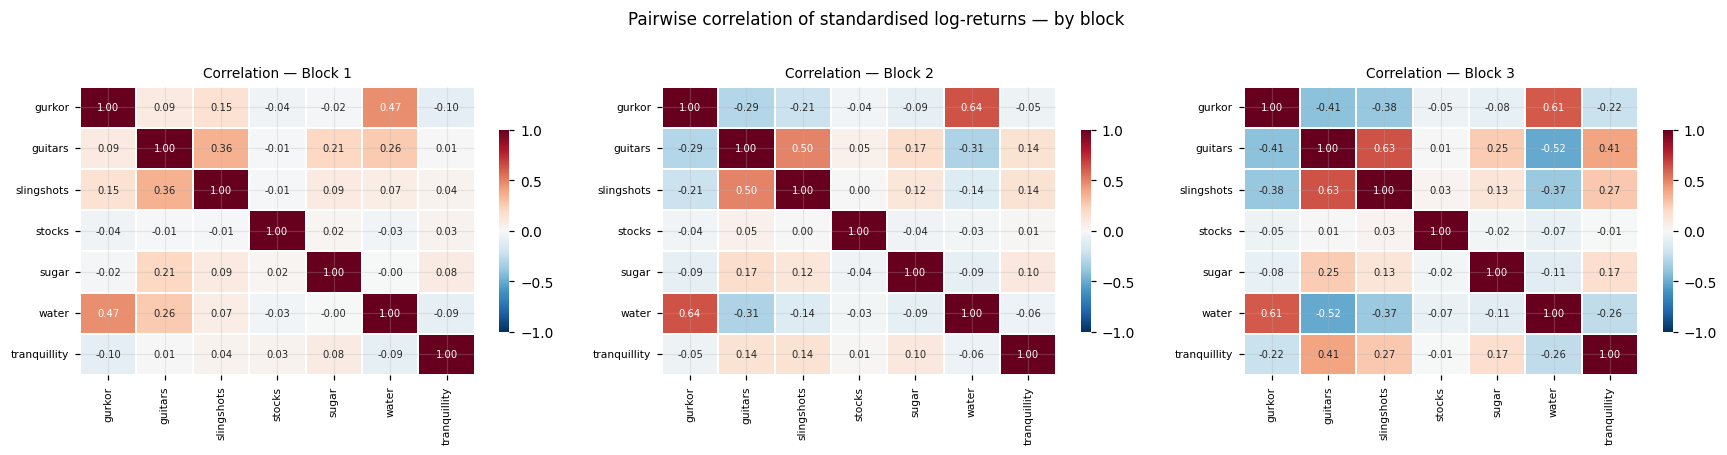

In [25]:
corr_matrices = {}
for name in ['block_1', 'block_2', 'block_3']:
    scaled = block_pca[name]['scaled']
    corr_matrices[name] = np.corrcoef(scaled.T)   # (7, 7)

# ── Per-block correlation heatmaps ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, ['block_1', 'block_2', 'block_3']):
    plot_correlation_heatmap(ax, corr_matrices[name],
                             f'Correlation — {BLOCK_LABELS[name]}')
fig.suptitle('Pairwise correlation of standardised log-returns — by block',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

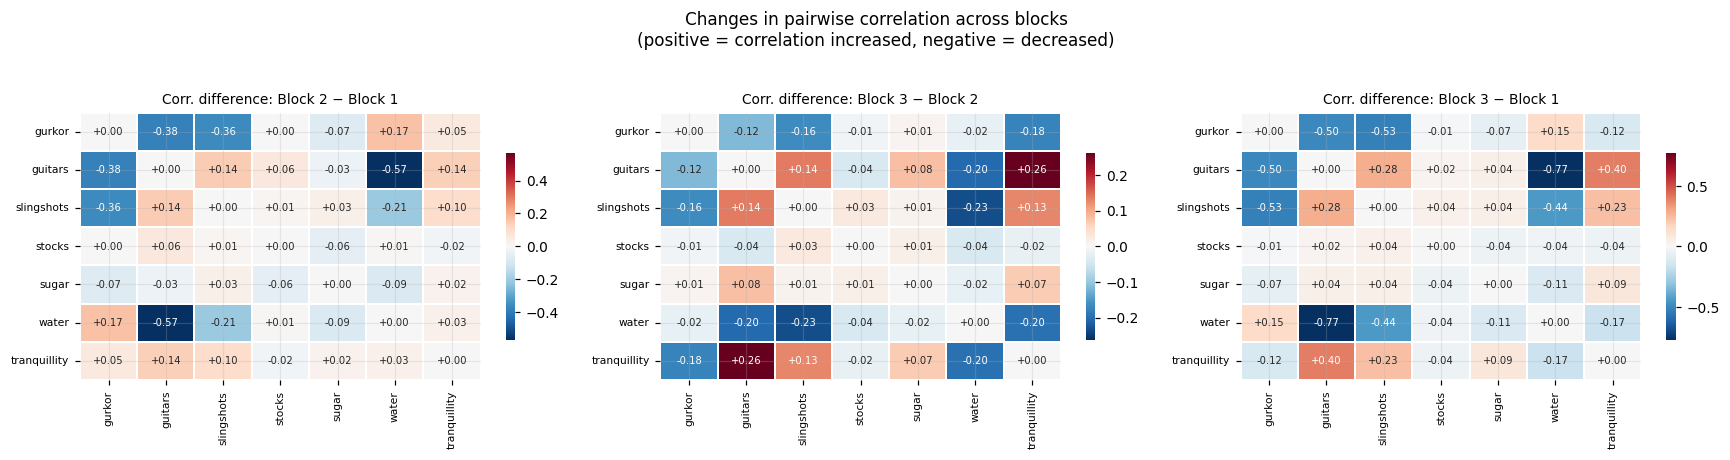


Largest absolute correlation changes (Block 3 – Block 1):
  gurkor vs guitars: -0.501
  gurkor vs slingshots: -0.528
  guitars vs slingshots: +0.279
  guitars vs water: -0.774
  guitars vs tranquillity: +0.399
  slingshots vs water: -0.444
  slingshots vs tranquillity: +0.231
  water vs tranquillity: -0.166


In [26]:
# ── Correlation difference heatmaps ──────────────────────────────────────────
diff_pairs = [
    ('block_1', 'block_2', 'Block 2 − Block 1'),
    ('block_2', 'block_3', 'Block 3 − Block 2'),
    ('block_1', 'block_3', 'Block 3 − Block 1'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (na, nb, title) in zip(axes, diff_pairs):
    diff = corr_matrices[nb] - corr_matrices[na]
    vmax = np.abs(diff).max()
    sns.heatmap(
        pd.DataFrame(diff, index=SERIES, columns=SERIES),
        ax=ax, cmap=CMAP_DIV, center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt='+.2f', annot_kws={'size': 6.5},
        linewidths=0.3, cbar_kws={'shrink': 0.7},
    )
    ax.set_title(f'Corr. difference: {title}', fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle('Changes in pairwise correlation across blocks\n'
             '(positive = correlation increased, negative = decreased)',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

# Largest changes
print('\nLargest absolute correlation changes (Block 3 – Block 1):')
diff_13 = corr_matrices['block_3'] - corr_matrices['block_1']
for i in range(len(SERIES)):
    for j in range(i+1, len(SERIES)):
        d = diff_13[i, j]
        if abs(d) > 0.15:
            print(f'  {SERIES[i]} vs {SERIES[j]}: {d:+.3f}')

## 9. Factor scores over time

Plotting PC1–PC3 factor scores within each block reveals whether the
dominant market factors are stable or exhibit volatility clustering or
trend shifts within the block.

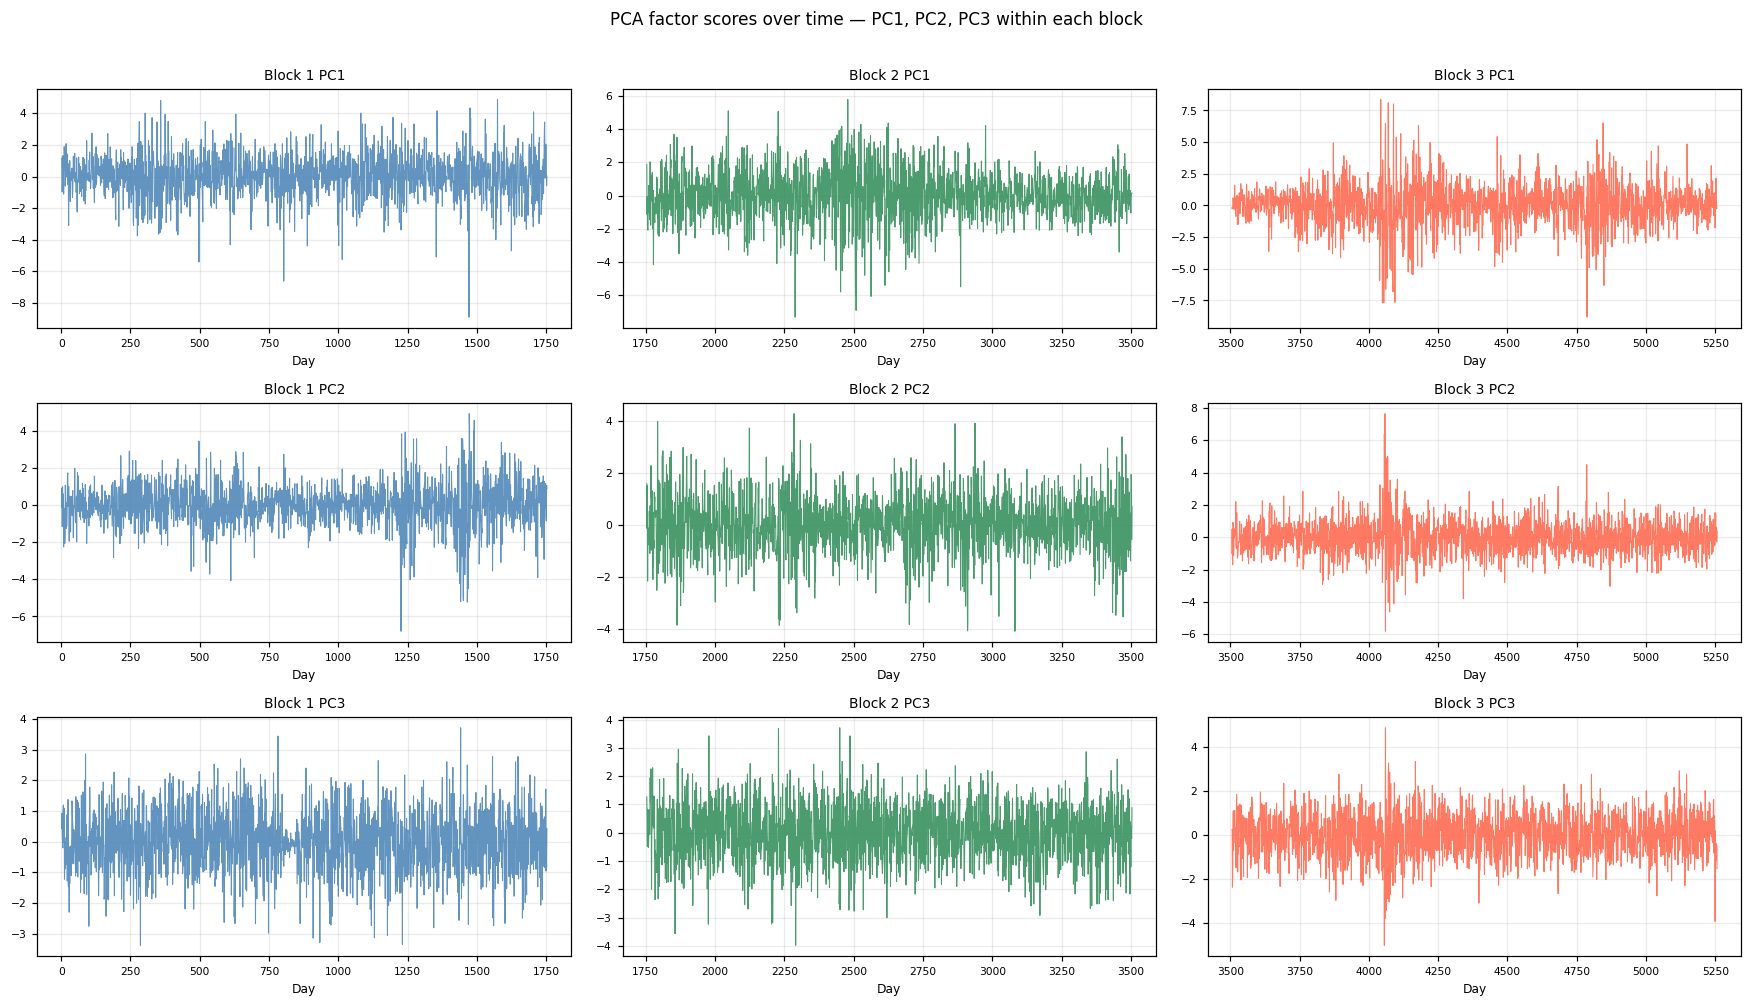

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=False)
COLORS = ['steelblue', 'seagreen', 'tomato']

for col, name in enumerate(['block_1', 'block_2', 'block_3']):
    m     = block_pca[name]
    block_day = BLOCK_DAYS[name][1:]   # drop first day (no return for it)
    n_show = min(3, m['n_comp'])
    for row in range(3):
        ax = axes[row, col]
        if row < n_show:
            ax.plot(block_day, m['scores'][:, row],
                    color=COLORS[col], lw=0.7, alpha=0.85)
            ax.set_title(f'{BLOCK_LABELS[name]} PC{row+1}', fontsize=9)
        else:
            ax.axis('off')
        ax.set_xlabel('Day', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle('PCA factor scores over time — PC1, PC2, PC3 within each block',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

Factor score diagnostics

Block 1
  PC          std    ACF(1)    ACF(5)
  PC1       1.3189    0.0851   -0.0236
  PC2       1.1432    0.0749    0.0160
  PC3       0.9973    0.0088    0.0050

Block 2
  PC          std    ACF(1)    ACF(5)
  PC1       1.4657    0.0897   -0.0231
  PC2       1.0895    0.0266    0.0225
  PC3       1.0081   -0.0500   -0.0039

Block 3
  PC          std    ACF(1)    ACF(5)
  PC1       1.6538    0.0615   -0.0317
  PC2       1.0372   -0.0512   -0.0154
  PC3       0.9748   -0.0313    0.0167


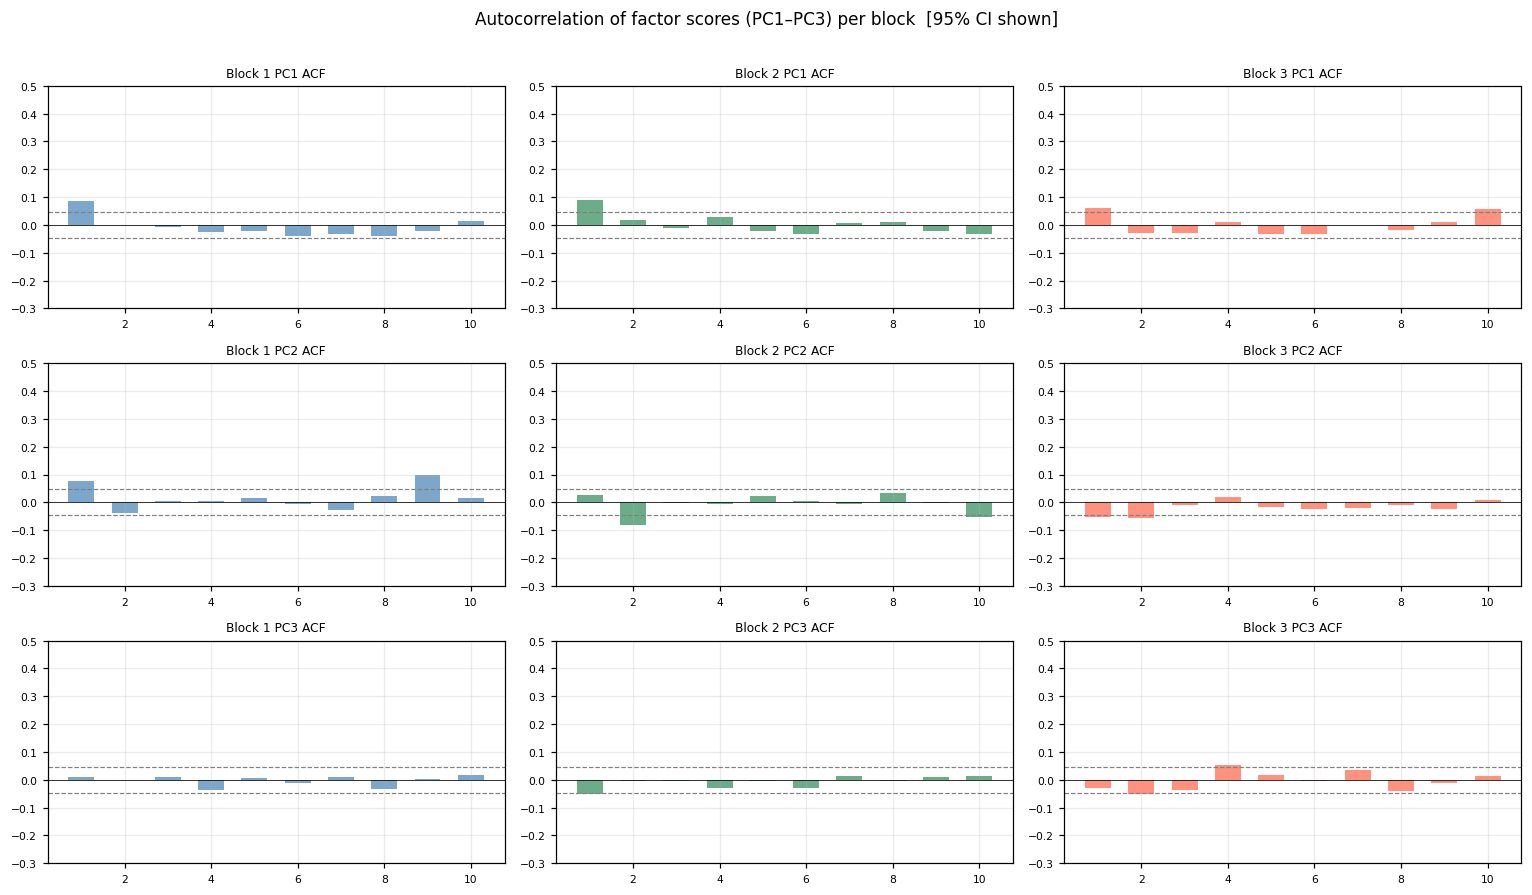

In [28]:
# ── Factor score diagnostics: volatility, autocorrelation ───────────────────
print('Factor score diagnostics\n' + '='*60)

ACF_NLAGS = 10

fig_acf, acf_axes = plt.subplots(3, 3, figsize=(14, 8))

for col, name in enumerate(['block_1', 'block_2', 'block_3']):
    m     = block_pca[name]
    n_show = min(3, m['n_comp'])
    print(f'\n{BLOCK_LABELS[name]}')
    print(f'  {"PC":<5}  {"std":>8}  {"ACF(1)":>8}  {"ACF(5)":>8}')
    for row in range(3):
        ax = acf_axes[row, col]
        if row < n_show:
            s   = m['scores'][:, row]
            std = np.std(s)
            a   = acf(s, nlags=ACF_NLAGS, fft=True)
            print(f'  PC{row+1:<4}  {std:>8.4f}  {a[1]:>8.4f}  {a[5]:>8.4f}')
            ax.bar(np.arange(1, ACF_NLAGS+1), a[1:], color=COLORS[col], alpha=0.7, width=0.6)
            ax.axhline(0, color='k', lw=0.5)
            ci = 1.96 / np.sqrt(len(s))
            ax.axhline( ci, color='grey', ls='--', lw=0.8)
            ax.axhline(-ci, color='grey', ls='--', lw=0.8)
            ax.set_title(f'{BLOCK_LABELS[name]} PC{row+1} ACF', fontsize=8)
            ax.set_ylim(-0.3, 0.5)
        else:
            ax.axis('off')
        ax.tick_params(labelsize=7)

fig_acf.suptitle('Autocorrelation of factor scores (PC1–PC3) per block  [95% CI shown]',
                 fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

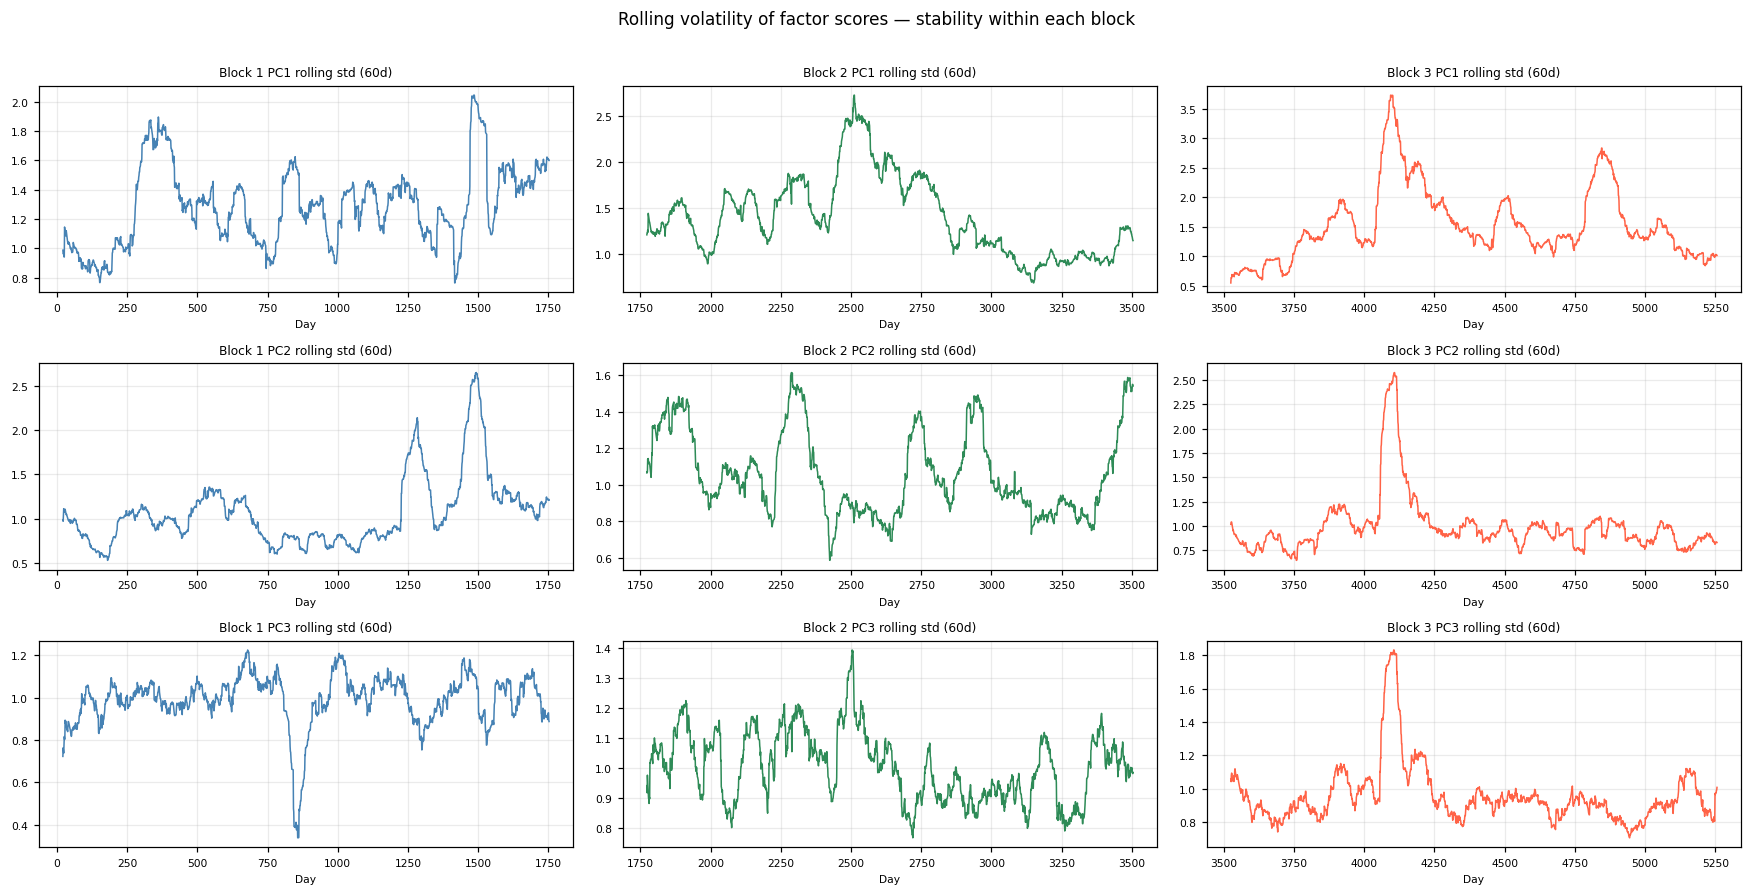

In [29]:
# ── Factor score rolling volatility (std over 60-day window) ─────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 8))

for col, name in enumerate(['block_1', 'block_2', 'block_3']):
    m          = block_pca[name]
    block_day  = BLOCK_DAYS[name][1:]
    n_show     = min(3, m['n_comp'])
    for row in range(3):
        ax = axes[row, col]
        if row < n_show:
            s   = pd.Series(m['scores'][:, row], index=block_day)
            vol = s.rolling(60, min_periods=20).std()
            ax.plot(vol.index, vol.values, color=COLORS[col], lw=1.0)
            ax.set_title(f'{BLOCK_LABELS[name]} PC{row+1} rolling std (60d)', fontsize=8)
        else:
            ax.axis('off')
        ax.tick_params(labelsize=7)
        ax.set_xlabel('Day', fontsize=7)

fig.suptitle('Rolling volatility of factor scores — stability within each block',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 10. PCA reconstruction quality

How well does the truncated PCA (components for ≥ 90 % variance) reproduce
each asset's standardised log-returns? A high reconstruction error means
that asset has idiosyncratic variation that the common factors do not capture.

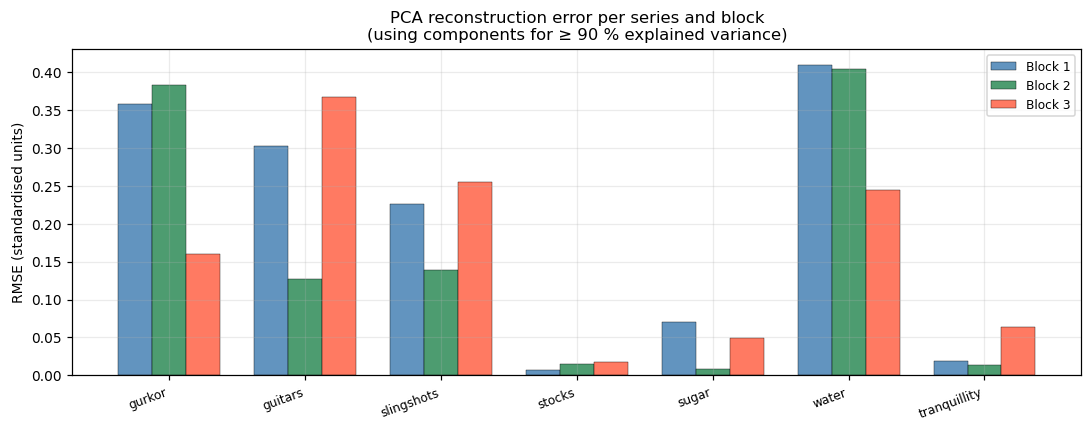

In [30]:
recon_errors = {}

for name in ['block_1', 'block_2', 'block_3']:
    m = block_pca[name]
    recon_errors[name] = compute_reconstruction_error(m['scaled'], m['pca'])

# ── Bar plot ─────────────────────────────────────────────────────────────────
x = np.arange(len(SERIES))
width = 0.25
colors = {'block_1': 'steelblue', 'block_2': 'seagreen', 'block_3': 'tomato'}

fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, label) in enumerate(BLOCK_LABELS.items()):
    ax.bar(x + i*width, recon_errors[name], width, label=label,
           color=colors[name], alpha=0.85, edgecolor='k', linewidth=0.3)

ax.set_xticks(x + width)
ax.set_xticklabels(SERIES, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('RMSE (standardised units)')
ax.set_title('PCA reconstruction error per series and block\n'
             f'(using components for ≥ 90 % explained variance)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
# ── Summary table ─────────────────────────────────────────────────────────────
recon_df = pd.DataFrame(
    {BLOCK_LABELS[k]: np.round(v, 4) for k, v in recon_errors.items()},
    index=SERIES
)
recon_df.index.name = 'Series'
recon_df['Mean'] = recon_df.mean(axis=1).round(4)
print('PCA reconstruction RMSE (standardised log-returns):')
display(recon_df.sort_values('Mean', ascending=False))

PCA reconstruction RMSE (standardised log-returns):


,Block 1,Block 2,Block 3,Mean
Series,,,,
water,0.4098,0.4042,0.2441,0.3527
gurkor,0.3584,0.3834,0.1604,0.3007
guitars,0.3027,0.1266,0.3676,0.2656
slingshots,0.2259,0.1388,0.2554,0.2067
sugar,0.0704,0.0083,0.0487,0.0425
tranquillity,0.0188,0.0142,0.0635,0.0322
stocks,0.0067,0.0152,0.0179,0.0133


## 11. VAR(2) as factor dynamics diagnostics (optional)

VAR is used here **only** to characterise the dynamic relationships between
PCA factors within each block. It is **not** used to produce a price forecast.

Inspecting VAR coefficient matrices and residual correlations tells us:
- Which factors Granger-cause which in each block.
- Whether the dynamic coupling between factors is stable across blocks.

In [32]:
def fit_var2(factors):
    return VAR(factors).fit(maxlags=2, ic=None)

var_models = {}
for name in ['block_1', 'block_2', 'block_3']:
    m = block_pca[name]
    var_models[name] = fit_var2(m['scores'])
    res = var_models[name]
    print(f'{BLOCK_LABELS[name]}: VAR(2) lag={res.k_ar}  stable={res.is_stable()}')

Block 1: VAR(2) lag=2  stable=True
Block 2: VAR(2) lag=2  stable=True
Block 3: VAR(2) lag=2  stable=True


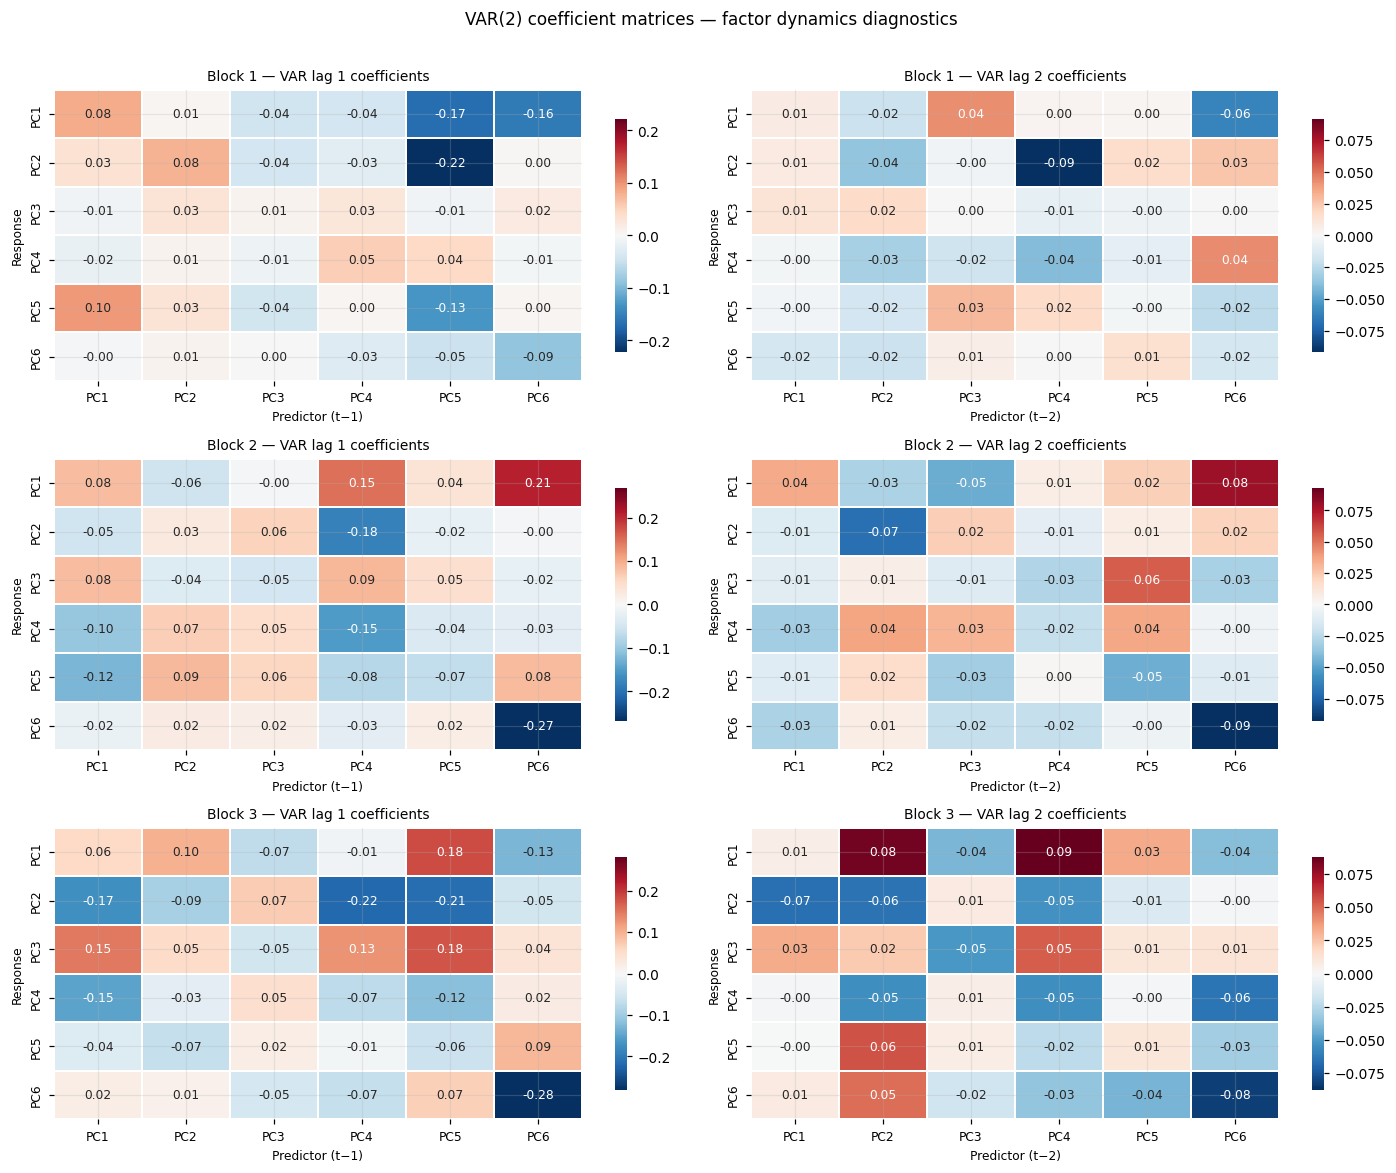

In [33]:
# ── VAR coefficient heatmaps (lag 1 and lag 2) ───────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 3.5 * 3))

for row, name in enumerate(['block_1', 'block_2', 'block_3']):
    res    = var_models[name]
    n_comp = block_pca[name]['n_comp']
    labels = [f'PC{i+1}' for i in range(res.k_ar * n_comp)]

    for lag_idx, lag in enumerate([1, 2]):
        ax   = axes[row, lag_idx]
        coef = res.coefs[lag - 1]   # (n_comp, n_comp)
        vmax = np.abs(coef).max() or 1
        sns.heatmap(
            pd.DataFrame(coef,
                         index   = [f'PC{i+1}' for i in range(coef.shape[0])],
                         columns = [f'PC{j+1}' for j in range(coef.shape[1])]),
            ax=ax, cmap=CMAP_DIV, center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.3, cbar_kws={'shrink': 0.8},
        )
        ax.set_title(f'{BLOCK_LABELS[name]} — VAR lag {lag} coefficients', fontsize=9)
        ax.set_xlabel('Predictor (t−{})'.format(lag), fontsize=8)
        ax.set_ylabel('Response', fontsize=8)
        ax.tick_params(labelsize=8)

fig.suptitle('VAR(2) coefficient matrices — factor dynamics diagnostics',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

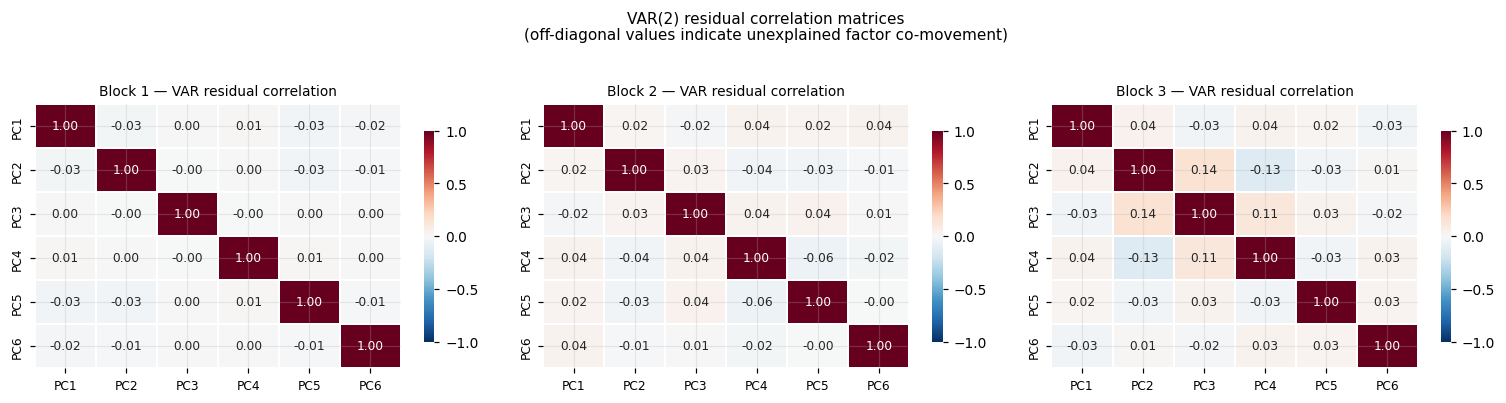

In [34]:
# ── Residual correlation heatmaps ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, name in zip(axes, ['block_1', 'block_2', 'block_3']):
    resid = var_models[name].resid
    rcorr = np.corrcoef(resid.T)
    n_comp = block_pca[name]['n_comp']
    pc_labels = [f'PC{i+1}' for i in range(n_comp)]
    sns.heatmap(
        pd.DataFrame(rcorr, index=pc_labels, columns=pc_labels),
        ax=ax, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 8},
        linewidths=0.3, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{BLOCK_LABELS[name]} — VAR residual correlation', fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle('VAR(2) residual correlation matrices\n'
             '(off-diagonal values indicate unexplained factor co-movement)',
             fontsize=10, y=1.03)
plt.tight_layout()
plt.show()

## 12. Key takeaways for extrapolation choice

The cell below produces an automated summary based on the analysis above.

In [35]:
print('='*70)
print('KEY TAKEAWAYS FOR EXTRAPOLATION CHOICE')
print('='*70)

# ── 1. Number of factors ─────────────────────────────────────────────────────
n_comps = [block_pca[n]['n_comp'] for n in ['block_1','block_2','block_3']]
print(f'\n1. DIMENSIONALITY')
print(f'   Components for 90% variance: Block1={n_comps[0]}, Block2={n_comps[1]}, Block3={n_comps[2]}')
if len(set(n_comps)) == 1:
    print('   => Stable: all blocks require the same number of factors.')
else:
    print('   => Unstable: the number of common factors changes across blocks.')

# ── 2. Loading stability ──────────────────────────────────────────────────────
print(f'\n2. LOADING STABILITY (avg max |cosine sim|)')
for na, nb, title in pairs:
    sim = sim_matrices[(na, nb)]
    avg = np.mean(np.max(sim, axis=1))
    flag = 'stable' if avg >= 0.80 else 'moderate' if avg >= 0.60 else 'unstable'
    print(f'   {title}: avg={avg:.3f}  [{flag}]')

# ── 3. Correlation structure ──────────────────────────────────────────────────
diff_magnitudes = {
    'Block1→Block2': np.abs(corr_matrices['block_2'] - corr_matrices['block_1'])[
        np.triu_indices(7, k=1)].mean(),
    'Block2→Block3': np.abs(corr_matrices['block_3'] - corr_matrices['block_2'])[
        np.triu_indices(7, k=1)].mean(),
    'Block1→Block3': np.abs(corr_matrices['block_3'] - corr_matrices['block_1'])[
        np.triu_indices(7, k=1)].mean(),
}
print(f'\n3. CORRELATION STRUCTURE SHIFT (mean |Δcorr|)')
for label, val in diff_magnitudes.items():
    flag = 'large' if val > 0.15 else 'moderate' if val > 0.07 else 'small'
    print(f'   {label}: {val:.4f}  [{flag}]')

# ── 4. Factor volatility ──────────────────────────────────────────────────────
print(f'\n4. PC1 FACTOR SCORE VOLATILITY (std)')
for name in ['block_1','block_2','block_3']:
    std = np.std(block_pca[name]['scores'][:, 0])
    print(f'   {BLOCK_LABELS[name]}: {std:.4f}')

# ── 5. Reconstruction quality ─────────────────────────────────────────────────
worst_series = recon_df['Mean'].idxmax()
print(f'\n5. PCA RECONSTRUCTION')
print(f'   Hardest series to represent (highest mean RMSE): {worst_series}')
print(f'   Mean reconstruction RMSE across series and blocks:')
for name in ['block_1','block_2','block_3']:
    print(f'   {BLOCK_LABELS[name]}: {recon_errors[name].mean():.4f}')

# ── 6. Block 3 similarity ─────────────────────────────────────────────────────
print(f'\n6. BLOCK 3 IS MOST SIMILAR TO: {closer}  '
      f'(avg max cosine sim to B1={avg_13:.3f}, to B2={avg_23:.3f})')

# ── 7. Narrative ──────────────────────────────────────────────────────────────
print(f'''
7. NARRATIVE FOR EXTRAPOLATION DECISION
   Based on the PCA loading comparison, correlation shifts, and factor dynamics:

   - If factor structure is broadly stable, a model trained on all available
     history may be acceptable.
   - If loadings or correlations shift substantially (especially Block 3 vs
     Block 1), the most recent block should be preferred for extrapolation,
     as it best reflects current market dynamics.
   - Assets with high reconstruction error have idiosyncratic variation that
     shared-factor models cannot capture; per-series models (e.g. ARIMA, GARCH)
     may be more appropriate for those series.
   - The VAR coefficient comparison shows whether cross-factor dynamics are
     persistent or regime-dependent, further informing the choice of a
     multivariate vs univariate extrapolation approach.
''')
print('='*70)

KEY TAKEAWAYS FOR EXTRAPOLATION CHOICE

1. DIMENSIONALITY
   Components for 90% variance: Block1=6, Block2=6, Block3=6
   => Stable: all blocks require the same number of factors.

2. LOADING STABILITY (avg max |cosine sim|)
   Block 1 vs Block 2: avg=0.736  [moderate]
   Block 2 vs Block 3: avg=0.778  [moderate]
   Block 1 vs Block 3: avg=0.654  [moderate]

3. CORRELATION STRUCTURE SHIFT (mean |Δcorr|)
   Block1→Block2: 0.1228  [moderate]
   Block2→Block3: 0.0939  [moderate]
   Block1→Block3: 0.1965  [large]

4. PC1 FACTOR SCORE VOLATILITY (std)
   Block 1: 1.3189
   Block 2: 1.4657
   Block 3: 1.6538

5. PCA RECONSTRUCTION
   Hardest series to represent (highest mean RMSE): water
   Mean reconstruction RMSE across series and blocks:
   Block 1: 0.1990
   Block 2: 0.1558
   Block 3: 0.1654

6. BLOCK 3 IS MOST SIMILAR TO: Block 2  (avg max cosine sim to B1=0.622, to B2=0.763)

7. NARRATIVE FOR EXTRAPOLATION DECISION
   Based on the PCA loading comparison, correlation shifts, and factor